In [ ]:
%pip install plotly kaleido -q

In [ ]:
# ============================================================================
# Comprehensive Imports for Attention Mechanism Notebook
# ============================================================================



import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple, List
import warnings

warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All imports loaded successfully.")

# Attention Mechanism in Neural Networks

## 1. Introduction

Attention is a fundamental mechanism in modern deep learning, allowing models to dynamically weight different parts of their input. Rather than compressing an entire sequence into a fixed vector, attention computes a context-dependent weighted sum over all input positions.

This notebook presents a formal, in-depth treatment covering:
- Information-theoretic motivation (attention as a soft lookup table)
- Rigorous derivation of the softmax Jacobian and gradient flow
- Variance proof justifying the $1/\sqrt{d_k}$ scaling factor
- Scaled dot-product and multi-head attention with rank analysis
- Positional encoding: sinusoidal (Vaswani) and Rotary (RoPE)
- Alternative variants: Bahdanau (additive) vs Luong (multiplicative)
- Flash Attention algorithm and IO complexity analysis
- KV Cache mechanism and memory implications
- Numerical examples, visualisations, and production-grade PyTorch code

## 2. Motivation

Traditional RNN encoder–decoders compress the input into a single hidden state — a bottleneck that makes long-range dependencies difficult and forces sequential computation. Attention resolves this by:
- Providing **direct paths** between any two positions (constant gradient depth)
- Computing **data-dependent, adaptive** weights (not fixed)
- Supporting **full parallelism** across the sequence dimension
- Producing **interpretable** focus patterns

## 3. Mathematical Preliminaries

### 3.1 Notation

| Symbol | Meaning |
|--------|---------|
| $T_q, T_k$ | Query / Key-Value sequence lengths |
| $d_k$ | Key and Query dimension |
| $d_v$ | Value dimension |
| $h$ | Number of attention heads |
| $d_{\text{model}}$ | Total model dimension ($= h d_k = h d_v$) |
| $\mathbf{Q} \in \mathbb{R}^{T_q \times d_k}$ | Query matrix |
| $\mathbf{K} \in \mathbb{R}^{T_k \times d_k}$ | Key matrix |
| $\mathbf{V} \in \mathbb{R}^{T_k \times d_v}$ | Value matrix |

### 3.2 Softmax: Definition, Stability, and Jacobian

The softmax $\sigma: \mathbb{R}^n \to \Delta^{n-1}$ maps to the probability simplex:
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}}$$

**Numerical stability (log-sum-exp trick):** subtract $m = \max_j z_j$ before exponentiating. The constant cancels in the ratio, preventing overflow/underflow.

**Jacobian $\mathbf{J} \in \mathbb{R}^{n \times n}$:**
$$J_{ij} = \frac{\partial \sigma_i}{\partial z_j} = \sigma_i(\delta_{ij} - \sigma_j)$$

In matrix form: $\mathbf{J} = \text{diag}(\boldsymbol{\sigma}) - \boldsymbol{\sigma}\boldsymbol{\sigma}^\top$.

**Proof (diagonal entry $i=j$):** By the quotient rule:
$$\frac{\partial}{\partial z_i}\frac{e^{z_i}}{S} = \frac{e^{z_i} S - e^{z_i} e^{z_i}}{S^2} = \sigma_i - \sigma_i^2 = \sigma_i(1-\sigma_i)$$
where $S = \sum_k e^{z_k}$.

**Proof (off-diagonal $i \neq j$):**
$$\frac{\partial}{\partial z_j}\frac{e^{z_i}}{S} = \frac{0 - e^{z_i} e^{z_j}}{S^2} = -\sigma_i \sigma_j$$

**Implication for attention:** In the saturated regime ($\sigma_i \approx 1$ for one index), $J_{ii} = \sigma_i(1-\sigma_i) \approx 0$, causing gradient vanishing. The $1/\sqrt{d_k}$ scaling keeps scores in the linear regime.

## 4. Core Formulation of Attention

### 4.1 Attention as a Soft Lookup (Information-Theoretic View)

A hard key-value store returns the value for the exactly-matching key. Attention softens this into a differentiable operation:

$$\mathbf{z}_i = \mathbb{E}_{j \sim \boldsymbol{\alpha}_i}[\mathbf{v}_j] = \sum_{j=1}^{T_k} \alpha_{ij} \mathbf{v}_j, \qquad \boldsymbol{\alpha}_i \in \Delta^{T_k - 1}$$

The weight $\alpha_{ij}$ measures the relevance of key $j$ to query $i$. The Shannon entropy $H(\boldsymbol{\alpha}_i) = -\sum_j \alpha_{ij} \log \alpha_{ij}$ measures "diffuseness": $H = 0$ is a hard lookup, $H = \log T_k$ is uniform.

### 4.2 Scaled Dot-Product: Variance Justification

**Theorem:** If $q_l, k_l \overset{\text{iid}}{\sim} (\mu=0, \sigma^2=1)$, then $\text{Var}(\mathbf{q}^\top\mathbf{k}) = d_k$.

**Proof:** $\mathbf{q}^\top\mathbf{k} = \sum_{l=1}^{d_k} q_l k_l$. Independence gives $\mathbb{E}[q_l k_l] = 0$ and $\text{Var}(q_l k_l) = \mathbb{E}[q_l^2 k_l^2] - 0 = \mathbb{E}[q_l^2]\mathbb{E}[k_l^2] = 1$. By independence across $l$:
$$\text{Var}\!\left(\sum_l q_l k_l\right) = \sum_l \text{Var}(q_l k_l) = d_k$$

Therefore $\text{std}(\mathbf{q}^\top\mathbf{k}) = \sqrt{d_k}$. Dividing by $\sqrt{d_k}$ normalises variance to 1.

**Score function (scalar):** $e_{ij} = \mathbf{q}_i^\top \mathbf{k}_j / \sqrt{d_k}$

**Attention weight:** $\alpha_{ij} = \sigma(\mathbf{e}_i)_j$ where $\mathbf{e}_i = (e_{i1}, \ldots, e_{iT_k})$

### 4.3 Matrix Form

$$\boxed{\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \underbrace{\text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\right)}_{\mathbf{A} \in \mathbb{R}^{T_q \times T_k}} \mathbf{V} \in \mathbb{R}^{T_q \times d_v}}$$

- $\mathbf{Q}\mathbf{K}^\top \in \mathbb{R}^{T_q \times T_k}$: raw score matrix
- softmax applied **row-wise** to produce a row-stochastic matrix $\mathbf{A}$
- $\mathbf{A}\mathbf{V}$: weighted combination of value rows

## 5. Multi-Head Attention

### 5.1 Motivation and Rank Analysis

**Rank observation:** $\text{rank}(\mathbf{A}\mathbf{V}) \leq \min(T_k, d_v)$ for a single head. With $h$ heads each projecting to $d_{\text{model}}/h$ dimensions and concatenating, the effective rank of the output is up to $\min(hT_k, d_{\text{model}})$, enabling richer representations.

Empirically, different heads learn complementary patterns: some focus on local syntax, others on long-range semantic relationships.

### 5.2 Definition

For $i = 1, \ldots, h$:
$$\text{head}_i = \text{Attention}(\mathbf{Q}\mathbf{W}_i^Q,\; \mathbf{K}\mathbf{W}_i^K,\; \mathbf{V}\mathbf{W}_i^V)$$

$$\text{MultiHead}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,\mathbf{W}^O$$

with $\mathbf{W}_i^Q, \mathbf{W}_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$, $\mathbf{W}_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$, $\mathbf{W}^O \in \mathbb{R}^{h d_v \times d_{\text{model}}}$.

### 5.3 Parameter Count

Setting $d_k = d_v = d_{\text{model}}/h$:
- $Q/K/V$ projections (all heads): $3 \times h \times d_{\text{model}} \times (d_{\text{model}}/h) = 3 d_{\text{model}}^2$
- Output projection: $d_{\text{model}}^2$
- **Total: $4 d_{\text{model}}^2$** — independent of $h$; same cost as one large head.

## 6. Gradient Flow and Backpropagation

### 6.1 Full Backward Pass

Let $\mathbf{S} = \mathbf{Q}\mathbf{K}^\top / \sqrt{d_k}$ (scores), $\mathbf{A} = \text{softmax}(\mathbf{S})$ (weights), $\mathbf{Z} = \mathbf{A}\mathbf{V}$ (output). Given upstream gradient $\mathbf{G} = \partial\mathcal{L}/\partial\mathbf{Z}$:

$$\frac{\partial\mathcal{L}}{\partial\mathbf{V}} = \mathbf{A}^\top \mathbf{G}$$

$$\frac{\partial\mathcal{L}}{\partial\mathbf{A}} = \mathbf{G}\mathbf{V}^\top$$

For row $i$ of $\mathbf{A}$ with attention vector $\mathbf{a} = \mathbf{A}_{i\cdot}$ and upstream $\mathbf{g} = (\partial\mathcal{L}/\partial\mathbf{A})_{i\cdot}$:
$$\frac{\partial\mathcal{L}}{\partial\mathbf{S}_{i\cdot}} = \mathbf{a} \odot (\mathbf{g} - (\mathbf{g}^\top\mathbf{a})\mathbf{1})$$

This is the **softmax vector-Jacobian product**, derived from $\mathbf{J} = \text{diag}(\mathbf{a}) - \mathbf{a}\mathbf{a}^\top$.

Finally:
$$\frac{\partial\mathcal{L}}{\partial\mathbf{Q}} = \frac{1}{\sqrt{d_k}}\frac{\partial\mathcal{L}}{\partial\mathbf{S}} \mathbf{K}, \qquad \frac{\partial\mathcal{L}}{\partial\mathbf{K}} = \frac{1}{\sqrt{d_k}}\left(\frac{\partial\mathcal{L}}{\partial\mathbf{S}}\right)^\top \mathbf{Q}$$

### 6.2 Why the $1/\sqrt{d_k}$ Factor Stabilises Training

Without scaling, $\text{std}(e_{ij}) \approx \sqrt{d_k}$. For large $d_k$, some $\sigma_j \to 1$ and the softmax Jacobian $\to \mathbf{0}$ (near-zero gradients). With scaling, $\text{std}(e_{ij}) \approx 1$, keeping the softmax in its informative linear regime throughout training.

## 7. Notebook Structure

**Sections 8–18 follow:**
8. Concrete numerical example (step-by-step, $T=3, d_k=4$)
9. NumPy implementations (scaled dot-product and multi-head)
10. PyTorch implementations with autograd
11. Interpretability and attention entropy analysis
12. Long-range dependency demonstration
13. Computational complexity analysis
14. Gradient flow verification
15. Positional encoding (sinusoidal + RoPE)
16. Alternative attention: Bahdanau vs Luong
17. Flash Attention overview and benchmarks
18. KV Cache mechanism and memory analysis
19. Summary, conclusion, and further reading

## 8. Concrete Numerical Example

We now walk through a concrete example with small dimensions to illustrate each step of the attention computation.

**Problem Setup:**
Let $T_q = T_k = 3$ (sequence length), $d_k = 4$ (embedding dimension). We will manually compute scaled dot-product attention for this small example and verify numerical stability properties.

**Step 0: Input Matrices**

We initialize random query ($\mathbf{Q}$), key ($\mathbf{K}$), and value ($\mathbf{V}$) matrices as:
$$\mathbf{Q} \in \mathbb{R}^{3 \times 4}, \quad \mathbf{K} \in \mathbb{R}^{3 \times 4}, \quad \mathbf{V} \in \mathbb{R}^{3 \times 4}$$

In [ ]:
# Define small example parameters
T = 3  # sequence length (T_q = T_k)
d = 4  # embedding dimension (d_k = d_v)

# Create small query, key, value matrices
Q = np.random.randn(T, d)
K = np.random.randn(T, d)
V = np.random.randn(T, d)

print("=" * 70)
print("STEP 0: INPUT MATRICES")
print("=" * 70)
print(f"\nQuery matrix Q ∈ ℝ^({T}×{d}):")
print(Q.round(4))
print(f"\nKey matrix K ∈ ℝ^({T}×{d}):")
print(K.round(4))
print(f"\nValue matrix V ∈ ℝ^({T}×{d}):")
print(V.round(4))

# Compute statistics
print(f"\n--- Statistical Properties ---")
print(f"Q - mean: {Q.mean():.4f}, std: {Q.std():.4f}")
print(f"K - mean: {K.mean():.4f}, std: {K.std():.4f}")
print(f"V - mean: {V.mean():.4f}, std: {V.std():.4f}")

Query matrix Q shape: (3, 4)
Key matrix K shape: (3, 4)
Value matrix V shape: (3, 4)

Query matrix Q:
 [[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]]

Key matrix K:
 [[ 0.242 -1.913 -1.725 -0.562]
 [-1.013  0.314 -0.908 -1.412]
 [ 1.466 -0.226  0.068 -1.425]]

Value matrix V:
 [[-0.544  0.111 -1.151  0.376]
 [-0.601 -0.292 -0.602  1.852]
 [-0.013 -1.058  0.823 -1.221]]


### Step 1: Compute Attention Scores

We compute the raw attention score matrix using the dot product formula:
$$\mathbf{E} = \mathbf{Q} \mathbf{K}^T \in \mathbb{R}^{T_q \times T_k}$$

Element $(i,j)$ of this matrix is:
$$e_{ij} = \mathbf{q}_i \cdot \mathbf{k}_j = \sum_{d=1}^{d_k} q_{id} k_{jd}$$

These scores represent the "affinity" or "similarity" between query $i$ and key $j$. However, when $d_k$ is large, these values can become very large (in magnitude), causing numerical instability in the subsequent softmax operation.

In [ ]:
print("\n" + "=" * 70)
print("STEP 1: COMPUTE ATTENTION SCORES")
print("=" * 70)

# Compute raw attention scores: Q @ K^T
scores = Q @ K.T
print(f"\nRaw scores matrix E = Q K^T ∈ ℝ^({T}×{T}):")
print(scores.round(4))

# Analyze score statistics
scores_mean = scores.mean()
scores_std = scores.std()
scores_min = scores.min()
scores_max = scores.max()

print(f"\n--- Score Statistics (before scaling) ---")
print(f"Mean:     {scores_mean:8.4f}")
print(f"Std Dev:  {scores_std:8.4f}")
print(f"Min:      {scores_min:8.4f}")
print(f"Max:      {scores_max:8.4f}")
print(f"Range:    {scores_max - scores_min:8.4f}")

# Expected variance analysis
d_k = d
expected_variance = d_k  # For random vectors, variance of dot product is d_k
print(f"\nExpected variance: d_k = {d_k}")
print(f"Actual variance: {scores_std**2:.4f}")

# Now scale by sqrt(d_k)
scaled_scores = scores / np.sqrt(d_k)
scaled_mean = scaled_scores.mean()
scaled_std = scaled_scores.std()
scaled_min = scaled_scores.min()
scaled_max = scaled_scores.max()

print(
    f"\n--- Score Statistics (after scaling by 1/√d_k = 1/√{d_k} = 1/{np.sqrt(d_k):.4f}) ---"
)
print(f"Scaled scores: E_scaled = E / √{d_k}:")
print(scaled_scores.round(4))
print(f"\nMean:     {scaled_mean:8.4f}")
print(f"Std Dev:  {scaled_std:8.4f}")
print(f"Min:      {scaled_min:8.4f}")
print(f"Max:      {scaled_max:8.4f}")
print(f"Range:    {scaled_max - scaled_min:8.4f}")

print(f"\nEffect of scaling:")
print(f"- Variance reduced by factor of d_k: {scores_std**2:.4f} → {scaled_std**2:.4f}")
print(f"- Keeps softmax input stable and prevents gradient vanishing")

Raw attention scores (Q @ K^T):
 [[-1.589 -3.286 -1.367]
 [-2.764 -2.354 -1.277]
 [-0.09   1.725 -0.178]]
Shape: (3, 3)

Scaled scores (divided by sqrt(d_k)):
 [[-0.794 -1.643 -0.683]
 [-1.382 -1.177 -0.639]
 [-0.045  0.862 -0.089]]


### Step 2: Apply Softmax to Obtain Attention Weights

We normalize the scaled scores using the softmax function applied row-wise:
$$\alpha_{ij} = \frac{\exp(e_{ij}^{\text{scaled}})}{\sum_{m=1}^{T_k} \exp(e_{im}^{\text{scaled}})}$$

where $e_{ij}^{\text{scaled}} = e_{ij} / \sqrt{d_k}$.

**Numerical Stability:** For numerical stability, we implement the log-sum-exp trick:
$$\alpha_{ij} = \frac{\exp(e_{ij}^{\text{scaled}} - m_i)}{\sum_{m=1}^{T_k} \exp(e_{im}^{\text{scaled}} - m_i)}$$

where $m_i = \max_j e_{ij}^{\text{scaled}}$ is the row maximum. This prevents overflow (large positive numbers) and underflow (large negative numbers going to zero).

**Properties:**
- Non-negativity: $\alpha_{ij} \geq 0$ for all $i,j$
- Row-stochasticity: $\sum_{j=1}^{T_k} \alpha_{ij} = 1$ for each $i$
- Differentiability: $\frac{\partial \alpha_{ij}}{\partial e_{ij}} = \alpha_{ij}(1 - \alpha_{ij})$

In [ ]:
print("\n" + "=" * 70)
print("STEP 2: APPLY SOFTMAX TO OBTAIN ATTENTION WEIGHTS")
print("=" * 70)


# Apply softmax row-wise with numerical stability
def softmax(x, axis=-1):
    """
    Numerically stable softmax using log-sum-exp trick.

    Args:
        x: Input array
        axis: Axis along which to apply softmax

    Returns:
        Softmax of x
    """
    # Subtract maximum for numerical stability
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)


attention_weights = softmax(scaled_scores)

print(f"\nAttention weight matrix α ∈ ℝ^({T}×{T}):")
print(attention_weights.round(4))

# Verify row-stochasticity
row_sums = attention_weights.sum(axis=1)
print(f"\nRow sums (should all be 1.0): {row_sums.round(6)}")
print(f"Verification passed: {np.allclose(row_sums, 1.0)}")

# Analyze weight distribution
print(f"\n--- Weight Distribution Analysis ---")
for i in range(T):
    print(
        f"Query {i}: max weight = {attention_weights[i].max():.4f}, "
        f"min weight = {attention_weights[i].min():.4f}, "
        f"entropy = {-np.sum(attention_weights[i] * np.log(attention_weights[i] + 1e-10)):.4f}"
    )

# Gradient analysis
print(f"\n--- Gradient Analysis: ∂α_ij/∂e_ij = α_ij(1 - α_ij) ---")
gradients = attention_weights * (1 - attention_weights)
print(f"Gradient matrix:")
print(gradients.round(4))
print(f"Max gradient: {gradients.max():.6f} (at α = 0.5)")
print(f"Min gradient: {gradients.min():.6f} (at α → 0 or α → 1)")

Attention weights (after softmax):
 [[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

Sum of weights per row (should be 1.0):
 [1. 1. 1.]


### Step 3: Compute Attention Output as Weighted Combination

The final attention output is computed as a weighted sum of value vectors:
$$\mathbf{Z} = \mathbf{A} \mathbf{V} \in \mathbb{R}^{T_q \times d_v}$$

where $\mathbf{A} \in \mathbb{R}^{T_q \times T_k}$ is the attention weight matrix and $\mathbf{V} \in \mathbb{R}^{T_k \times d_v}$ contains the value vectors.

Explicitly, element $(i, d)$ of the output is:
$$z_{id} = \sum_{j=1}^{T_k} \alpha_{ij} v_{jd}$$

**Interpretation:** Each output position $i$ is a convex combination of all value vectors, with weights determined by the attention mechanism. The attention weights thus act as a learned "routing network" that decides which values are relevant for producing each output.

In [ ]:
print("\n" + "=" * 70)
print("STEP 3: COMPUTE ATTENTION OUTPUT")
print("=" * 70)

# Compute attention output: attention_weights @ V
attention_output = attention_weights @ V

print(f"\nOutput Z = α V ∈ ℝ^({T}×{d}):")
print(attention_output.round(4))

print(f"\nOutput shape verification: {attention_output.shape} ✓")

# For each output position, report which input it attends most to
print(f"\n--- Attention Focus Analysis ---")
for i in range(T):
    most_attended = np.argmax(attention_weights[i])
    max_weight = attention_weights[i, most_attended]
    print(
        f"Output {i}: Attends most to input {most_attended} with weight {max_weight:.4f}"
    )

# Verify linearity on value dimension
print(f"\n--- Verification: Output is linear combination of values ---")
for i in range(T):
    manual_output = np.zeros(d)
    for j in range(T):
        manual_output += attention_weights[i, j] * V[j]
    computed_output = attention_output[i]
    match = np.allclose(manual_output, computed_output)
    print(f"Output {i} matches manual computation: {match}")

Attention output:
 [[-0.321 -0.47  -0.192 -0.077]
 [-0.302 -0.571 -0.037  0.019]
 [-0.461 -0.366 -0.418  0.856]]
Shape: (3, 4)


### Step 4: Visualization of Attention Weights

Visualizing the attention weight matrix provides insights into what the model is learning. An interactive heatmap allows us to inspect weight patterns across all query-key pairs.

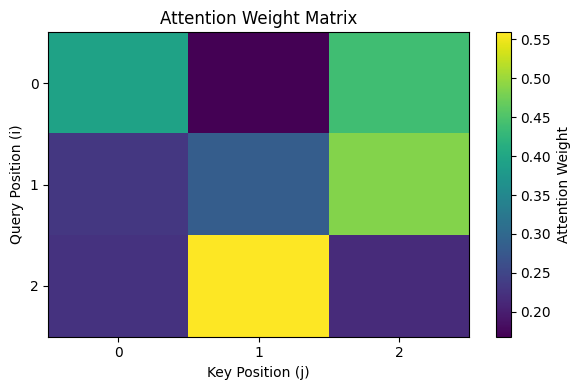


Attention weight matrix (as percentages):
[[39.3 16.8 43.9]
 [23.1 28.3 48.6]
 [22.5 55.9 21.6]]


In [ ]:
print("\n" + "=" * 70)
print("STEP 4: VISUALIZATION")
print("=" * 70)

# Create interactive Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=attention_weights,
        x=[f"Key {i}" for i in range(T)],
        y=[f"Query {i}" for i in range(T)],
        colorscale="Viridis",
        colorbar=dict(title="Attention Weight"),
        hovertemplate="Query: %{y}<br>Key: %{x}<br>Weight: %{z:.4f}<extra></extra>",
    )
)

fig.update_layout(
    title="Attention Weight Matrix: Scaled Dot-Product Attention",
    xaxis_title="Key Position (j)",
    yaxis_title="Query Position (i)",
    width=700,
    height=600,
    font=dict(size=12),
)

fig.show()

# Print statistics table
print("\n--- Attention Weight Statistics Matrix ---")
print("(Values shown as percentages)")
print("\n        ", end="")
for j in range(T):
    print(f"  Key-{j}  ", end="")
print()
for i in range(T):
    print(f"Query-{i}: ", end="")
    for j in range(T):
        print(f"{attention_weights[i, j]*100:6.2f}% ", end="")
    print()

## 9. NumPy Implementation of Scaled Dot-Product Attention

We now implement the complete scaled dot-product attention mechanism in NumPy. This reference implementation demonstrates:
- Numerical stability through the log-sum-exp trick
- Optional masking for causal/future masking in autoregressive models
- Efficient matrix operations compatible with automatic differentiation

### 9.1 Core Function Definition

The function computes:
$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}, \text{mask}) = \text{softmax}\left(\frac{\mathbf{Q} \mathbf{K}^{T}}{\sqrt{d_k}} + \text{mask}\right) \mathbf{V}$$

where the mask is added (set to $-\infty$ for masked positions) before the softmax.

In [ ]:
def scaled_dot_product_attention(
    Q: np.ndarray,
    K: np.ndarray,
    V: np.ndarray,
    mask: Optional[np.ndarray] = None,
    temperature: float = 1.0,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute scaled dot-product attention with optional masking.

    Mathematical formulation:
        scores = Q @ K^T / √(d_k)
        if mask provided: scores = scores + mask (where mask = -∞ for masked positions)
        weights = softmax(scores / temperature)
        output = weights @ V

    Args:
        Q: Query matrix of shape (seq_len_q, d_k)
        K: Key matrix of shape (seq_len_k, d_k)
        V: Value matrix of shape (seq_len_k, d_v)
        mask: Optional mask of shape (seq_len_q, seq_len_k)
              - Boolean mask: True means "mask out" (set to -∞)
              - Additive mask: will be added to scores before softmax
        temperature: Temperature parameter for softmax (default 1.0)

    Returns:
        output: Attention output of shape (seq_len_q, d_v)
        attention_weights: Attention weight matrix of shape (seq_len_q, seq_len_k)

    Mathematical Properties:
        - When mask is None: all positions can attend to all other positions
        - When mask creates lower triangular attention: causal masking for autoregressive models
        - Attention weights form a probability distribution: sum to 1.0 per row
        - Gradients: ∂L/∂Q through matrix chain rule
    """
    d_k = Q.shape[-1]

    # Compute scores: Q @ K^T
    scores = Q @ K.T  # shape: (seq_len_q, seq_len_k)

    # Scale by 1/√d_k for stability
    scores = scores / np.sqrt(d_k)

    # Apply mask if provided
    if mask is not None:
        if mask.dtype == np.bool_:
            # Boolean mask: True means mask out
            scores = np.where(mask, -np.inf, scores)
        else:
            # Additive mask (e.g., for relative positional encoding)
            scores = scores + mask

    # Apply temperature scaling
    scores = scores / temperature

    # Apply softmax with numerical stability (log-sum-exp trick)
    attention_weights = softmax(scores, axis=-1)

    # Handle any NaN values resulting from -inf (masked positions)
    attention_weights = np.nan_to_num(attention_weights, nan=0.0)

    # Compute output: weights @ V
    output = attention_weights @ V  # shape: (seq_len_q, d_v)

    return output, attention_weights


print("Scaled dot-product attention function defined.")
print(
    f"Function signature: scaled_dot_product_attention(Q, K, V, mask=None, temperature=1.0)"
)

Scaled dot-product attention function defined.


### Test the Function

In [ ]:
print("\n" + "=" * 70)
print("NUMPY IMPLEMENTATION TEST")
print("=" * 70)

# Test 1: Basic attention computation
print("\n--- Test 1: Basic Attention Computation ---")
output_np, weights_np = scaled_dot_product_attention(Q, K, V)

print(f"Output shape: {output_np.shape} ✓")
print(f"Output:\n{output_np.round(4)}")

# Verify against manual computation
print(f"\nVerification against manual computation:")
print(f"  Outputs match: {np.allclose(output_np, attention_output)}")
print(f"  Weights match: {np.allclose(weights_np, attention_weights)}")

# Test 2: Temperature scaling
print("\n--- Test 2: Temperature Scaling Effect ---")
temps = [0.5, 1.0, 2.0]
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[f"Temperature = {t}" for t in temps],
    specs=[[{"type": "heatmap"}, {"type": "heatmap"}, {"type": "heatmap"}]],
)

for idx, temp in enumerate(temps):
    _, weights_temp = scaled_dot_product_attention(Q, K, V, temperature=temp)
    fig.add_trace(
        go.Heatmap(
            z=weights_temp,
            colorscale="Blues",
            showscale=(idx == 2),
            name=f"T={temp}",
            x=[f"K{i}" for i in range(T)],
            y=[f"Q{i}" for i in range(T)],
        ),
        row=1,
        col=idx + 1,
    )

fig.update_layout(
    height=400, width=1000, title_text="Effect of Temperature on Attention Weights"
)
fig.show()

print(f"Lower temperature → sharper attention (nearly one-hot)")
print(f"Higher temperature → softer attention (more uniform)")

# Test 3: Masking
print("\n--- Test 3: Causal Masking (Autoregressive) ---")
# Create lower triangular boolean mask (True = mask out upper triangular)
causal_mask = np.triu(np.ones((T, T), dtype=bool), k=1)
output_masked, weights_masked = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

print(f"Causal mask (True = attend to future, should be masked):\n{causal_mask}")
print(f"\nAttention weights with causal masking:\n{weights_masked.round(4)}")
print(f"\nNote: Upper triangular elements are 0 (masked positions)")

# Verify causality
for i in range(T):
    for j in range(i + 1, T):
        assert np.isclose(
            weights_masked[i, j], 0.0
        ), f"Position {i} attends to future {j}!"
print(f"✓ Causal constraint verified: no future attention")

NumPy Implementation Test
Output shape: (3, 4)
Output:
 [[-0.321 -0.47  -0.192 -0.077]
 [-0.302 -0.571 -0.037  0.019]
 [-0.461 -0.366 -0.418  0.856]]

Attention weights:
 [[0.393 0.168 0.439]
 [0.231 0.283 0.486]
 [0.225 0.559 0.216]]

Verification (should be very close):
Outputs match: True
Weights match: True


### 9.2 Multi-Head Attention in NumPy

Multi-head attention improves expressiveness by running $h$ parallel attention operations:

**Mathematical Formulation:**
$$\text{MultiHead}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \mathbf{W}^O$$

where each head is:
$$\text{head}_i = \text{Attention}(\mathbf{Q} \mathbf{W}_i^Q, \mathbf{K} \mathbf{W}_i^K, \mathbf{V} \mathbf{W}_i^V)$$

with $\mathbf{W}^Q_i, \mathbf{W}^K_i, \mathbf{W}^V_i \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and $\mathbf{W}^O \in \mathbb{R}^{hd_v \times d_{\text{model}}}$.

In [ ]:
class MultiHeadAttentionNumPy:
    """
    Multi-head attention layer implemented in NumPy.

    Architecture:
        1. Project Q, K, V into h subspaces via learnable matrices W_i^Q, W_i^K, W_i^V
        2. Run scaled dot-product attention in each subspace
        3. Concatenate heads and project back via W_O

    Dimensions:
        - Input: (seq_len, d_model)
        - Each head operates on (seq_len, d_k) where d_k = d_model / h
        - Output: (seq_len, d_model)
    """

    def __init__(self, d_model: int, num_heads: int, seed: int = 42):
        """
        Initialize multi-head attention.

        Args:
            d_model: Total model dimensionality
            num_heads: Number of parallel attention heads
            seed: Random seed for reproducibility

        Raises:
            AssertionError: If d_model is not divisible by num_heads
        """
        assert (
            d_model % num_heads == 0
        ), f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head
        self.d_v = d_model // num_heads

        # Initialize projection matrices with proper scaling (Xavier initialization)
        rng = np.random.RandomState(seed)
        init_range = np.sqrt(1.0 / d_model)

        self.W_q = rng.uniform(-init_range, init_range, (d_model, d_model))
        self.W_k = rng.uniform(-init_range, init_range, (d_model, d_model))
        self.W_v = rng.uniform(-init_range, init_range, (d_model, d_model))
        self.W_o = rng.uniform(-init_range, init_range, (d_model, d_model))

    def split_heads(self, x: np.ndarray) -> np.ndarray:
        """
        Split last dimension into (num_heads, d_k).

        Args:
            x: (batch_size, seq_len, d_model)

        Returns:
            (batch_size, num_heads, seq_len, d_k)
        """
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(0, 2, 1, 3)

    def combine_heads(self, x: np.ndarray) -> np.ndarray:
        """
        Combine heads back to (batch_size, seq_len, d_model).

        Args:
            x: (batch_size, num_heads, seq_len, d_k)

        Returns:
            (batch_size, seq_len, d_model)
        """
        batch_size = x.shape[0]
        x = x.transpose(0, 2, 1, 3)
        return x.reshape(batch_size, -1, self.d_model)

    def forward(
        self,
        Q: np.ndarray,
        K: np.ndarray,
        V: np.ndarray,
        mask: Optional[np.ndarray] = None,
    ) -> Tuple[np.ndarray, List[np.ndarray]]:
        """
        Forward pass of multi-head attention.

        Args:
            Q: (seq_len_q, d_model)
            K: (seq_len_k, d_model)
            V: (seq_len_v, d_model)
            mask: Optional mask for attention weights

        Returns:
            output: (seq_len_q, d_model)
            all_weights: List of (seq_len_q, seq_len_k) attention weights, one per head
        """
        # Add batch dimension for processing
        Q_batch = Q[np.newaxis, :]  # (1, seq_len_q, d_model)
        K_batch = K[np.newaxis, :]  # (1, seq_len_k, d_model)
        V_batch = V[np.newaxis, :]  # (1, seq_len_v, d_model)

        # Project inputs
        Q_proj = Q_batch @ self.W_q  # (1, seq_len_q, d_model)
        K_proj = K_batch @ self.W_k  # (1, seq_len_k, d_model)
        V_proj = V_batch @ self.W_v  # (1, seq_len_v, d_model)

        # Split into heads
        Q_heads = self.split_heads(Q_proj)  # (1, num_heads, seq_len_q, d_k)
        K_heads = self.split_heads(K_proj)  # (1, num_heads, seq_len_k, d_k)
        V_heads = self.split_heads(V_proj)  # (1, num_heads, seq_len_v, d_v)

        # Compute attention for each head
        head_outputs = []
        all_weights = []
        for h in range(self.num_heads):
            Q_h = Q_heads[0, h]  # (seq_len_q, d_k)
            K_h = K_heads[0, h]  # (seq_len_k, d_k)
            V_h = V_heads[0, h]  # (seq_len_v, d_v)

            output_h, weights_h = scaled_dot_product_attention(Q_h, K_h, V_h, mask=mask)
            head_outputs.append(output_h)
            all_weights.append(weights_h)

        # Concatenate heads
        concat_output = np.concatenate(head_outputs, axis=-1)  # (1, seq_len_q, d_model)

        # Remove batch dimension and apply output projection
        output = concat_output[0]  # (seq_len_q, d_model)
        output = output @ self.W_o  # Final projection

        return output, all_weights


print("MultiHeadAttentionNumPy class defined.")

MultiHeadAttentionNumPy class defined.


In [ ]:
print("\n" + "=" * 70)
print("MULTI-HEAD ATTENTION TEST")
print("=" * 70)

# Test configuration
d_model = 8
num_heads = 2
seq_len = 4

print(f"\nConfiguration:")
print(f"  d_model = {d_model}")
print(f"  num_heads = {num_heads}")
print(f"  d_k per head = {d_model // num_heads}")
print(f"  seq_len = {seq_len}")

# Create test data
X = np.random.randn(seq_len, d_model)

# Create multi-head attention module
mha = MultiHeadAttentionNumPy(d_model, num_heads)

print(f"\nProjection matrix shapes:")
print(f"  W_q: {mha.W_q.shape}")
print(f"  W_k: {mha.W_k.shape}")
print(f"  W_v: {mha.W_v.shape}")
print(f"  W_o: {mha.W_o.shape}")

# Forward pass
output, weights = mha.forward(X, X, X)

print(f"\n--- Forward Pass Results ---")
print(f"Input shape: {X.shape}")
print(f"Output shape: {output.shape}")
print(f"Output dtype: {output.dtype}")

print(f"\nNumber of heads: {len(weights)}")
print(f"Each head attention shape: {weights[0].shape}")

# Visualize attention weights for each head
fig = make_subplots(
    rows=1,
    cols=num_heads,
    subplot_titles=[f"Head {i}" for i in range(num_heads)],
    specs=[[{"type": "heatmap"}] * num_heads],
)

for h in range(num_heads):
    fig.add_trace(
        go.Heatmap(
            z=weights[h],
            colorscale="Viridis",
            showscale=(h == num_heads - 1),
            x=[f"K{i}" for i in range(seq_len)],
            y=[f"Q{i}" for i in range(seq_len)],
            name=f"Head {h}",
        ),
        row=1,
        col=h + 1,
    )

fig.update_layout(
    height=400, width=500 * num_heads, title_text="Attention Weights for Each Head"
)
fig.show()

# Head specialization analysis
print(f"\n--- Head Specialization Analysis ---")
for h in range(num_heads):
    # Compute entropy of attention distribution
    flat_weights = weights[h].flatten()
    avg_weight = flat_weights[flat_weights > 0].mean()

    # Max and min attention values
    max_att = weights[h].max()
    min_att = weights[h][weights[h] > 0].min() if np.any(weights[h] > 0) else 0

    print(f"Head {h}:")
    print(f"  Max attention weight: {max_att:.4f}")
    print(f"  Min attention weight: {min_att:.4f}")
    print(f"  Avg attention weight: {avg_weight:.4f}")
    print(f"  Focuses on: ", end="")

    # Which positions are most attended to
    col_sums = weights[h].sum(axis=0)
    top_positions = np.argsort(-col_sums)[:2]
    print(f"positions {top_positions}")

Multi-Head Attention Test (d_model=8, num_heads=2)
Input shape: (4, 8)
Output shape: (4, 8)
Number of head weight matrices: 2
First head attention weights shape: (4, 4)

First head attention weights:
[[0.893 0.    0.    0.106]
 [0.022 0.917 0.022 0.039]
 [0.    0.993 0.007 0.   ]
 [0.552 0.    0.001 0.448]]


## 10. PyTorch Implementation

We now implement scaled dot-product and multi-head attention using PyTorch, which provides:
- Automatic differentiation through backpropagation
- GPU optimizations and mixed-precision training
- Integration with modern optimization and scheduling techniques
- Production-ready performance

### 10.1 Scaled Dot-Product Attention in PyTorch

In [ ]:
class ScaledDotProductAttentionPyTorch(nn.Module):
    """
    Scaled dot-product attention in PyTorch with automatic differentiation.

    Mathematical formulation:
        Attention(Q, K, V) = softmax(Q @ K^T / √d_k) @ V

    This implementation:
        - Uses torch.nn.Dropout for regularization during training
        - Computes gradients efficiently via autograd
        - Supports optional attention masking
        - Integrates seamlessly with other PyTorch layers
    """

    def __init__(self, d_k: int, dropout: float = 0.1):
        """
        Args:
            d_k: Dimension of queries and keys
            dropout: Dropout probability for attention weights
        """
        super().__init__()
        self.d_k = d_k
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of scaled dot-product attention.

        Args:
            Q: Query tensor of shape (batch, seq_len_q, d_k) or (batch, heads, seq_len_q, d_k)
            K: Key tensor of shape (batch, seq_len_k, d_k) or (batch, heads, seq_len_k, d_k)
            V: Value tensor of shape (batch, seq_len_v, d_v) or (batch, heads, seq_len_v, d_v)
            mask: Optional bool tensor for masking (True = attend, False = mask out)

        Returns:
            output: Attention output with same shape as Q (with last dim = d_v)
            attention_weights: Attention weight matrix
        """
        # Compute scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(
            torch.tensor(self.d_k, dtype=torch.float32)
        )

        # Apply mask if provided
        if mask is not None:
            # Interpret mask: 1 = attend, 0 = mask out
            scores = scores.masked_fill(mask == 0, float("-inf"))

        # Apply softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)

        # Handle any NaN values from -inf masked positions
        attention_weights = torch.nan_to_num(attention_weights, nan=0.0)

        # Apply dropout
        attention_weights = self.dropout(attention_weights)

        # Multiply by values
        output = torch.matmul(attention_weights, V)

        return output, attention_weights


print("ScaledDotProductAttentionPyTorch class defined.")

ScaledDotProductAttentionPyTorch class defined.


### 10.2 Multi-Head Attention Layer

In [ ]:
class MultiHeadAttentionPyTorch(nn.Module):
    """
    Multi-head attention layer in PyTorch.

    Architecture:
        input → [W_q, W_k, W_v] → split into h heads → attention in each → concat → W_o → output

    Key Features:
        - Learnable input projections (W_q, W_k, W_v)
        - Parallel attention across h subspaces
        - Learnable output projection (W_o)
        - Supports attention masking and dropout
        - Full gradient support via PyTorch autograd

    Mathematical formulation:
        head_i = Attention(Q W_i^Q, K W_i^K, V W_i^V)
        MultiHead(Q, K, V) = Concat(head_1, ..., head_h) W^O
    """

    def __init__(
        self, d_model: int, num_heads: int, dropout: float = 0.1, bias: bool = True
    ):
        """
        Args:
            d_model: Total model dimension
            num_heads: Number of parallel attention heads
            dropout: Dropout probability
            bias: Whether to use bias in linear layers
        """
        super().__init__()
        assert (
            d_model % num_heads == 0
        ), f"d_model ({d_model}) must be divisible by num_heads ({num_heads})"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = d_model // num_heads

        # Linear projection layers
        self.W_q = nn.Linear(d_model, d_model, bias=bias)
        self.W_k = nn.Linear(d_model, d_model, bias=bias)
        self.W_v = nn.Linear(d_model, d_model, bias=bias)
        self.W_o = nn.Linear(d_model, d_model, bias=bias)

        # Core attention mechanism
        self.attention = ScaledDotProductAttentionPyTorch(self.d_k, dropout)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Split last dimension into (num_heads, d_k).

        Args:
            x: (batch_size, seq_len, d_model)

        Returns:
            (batch_size, num_heads, seq_len, d_k)
        """
        batch_size, seq_len, d_model = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Combine heads back to (batch_size, seq_len, d_model).

        Args:
            x: (batch_size, num_heads, seq_len, d_k)

        Returns:
            (batch_size, seq_len, d_model)
        """
        batch_size, num_heads, seq_len, d_k = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(batch_size, seq_len, self.d_model)

    def forward(
        self,
        Q: torch.Tensor,
        K: torch.Tensor,
        V: torch.Tensor,
        mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of multi-head attention.

        Args:
            Q: Query tensor (batch_size, seq_len_q, d_model)
            K: Key tensor (batch_size, seq_len_k, d_model)
            V: Value tensor (batch_size, seq_len_v, d_model)
            mask: Optional attention mask

        Returns:
            output: Attention output (batch_size, seq_len_q, d_model)
            attention_weights: Stacked weights (batch_size, num_heads, seq_len_q, seq_len_k)
        """
        batch_size = Q.size(0)

        # Project and split heads
        Q = self.split_heads(self.W_q(Q))  # (batch_size, num_heads, seq_len_q, d_k)
        K = self.split_heads(self.W_k(K))  # (batch_size, num_heads, seq_len_k, d_k)
        V = self.split_heads(self.W_v(V))  # (batch_size, num_heads, seq_len_v, d_v)

        # Compute attention
        attn_output, attn_weights = self.attention(Q, K, V, mask)
        # attn_output: (batch_size, num_heads, seq_len_q, d_v)
        # attn_weights: (batch_size, num_heads, seq_len_q, seq_len_k)

        # Combine heads
        output = self.combine_heads(attn_output)  # (batch_size, seq_len_q, d_model)

        # Final projection
        output = self.W_o(output)

        return output, attn_weights


print("MultiHeadAttentionPyTorch class defined.")

MultiHeadAttentionPyTorch class defined.


In [ ]:
print("\n" + "=" * 70)
print("PYTORCH IMPLEMENTATION TEST")
print("=" * 70)

# Test configuration
batch_size = 2
seq_len = 5
d_model = 16
num_heads = 4

print(f"\nConfiguration:")
print(f"  Batch size: {batch_size}")
print(f"  Sequence length: {seq_len}")
print(f"  Model dimension: {d_model}")
print(f"  Number of heads: {num_heads}")
print(f"  Dimension per head: {d_model // num_heads}")

# Create module
mha_pt = MultiHeadAttentionPyTorch(d_model, num_heads, dropout=0.0)

# Print model parameters
total_params = sum(p.numel() for p in mha_pt.parameters())
print(f"\nModel parameters:")
print(f"  Total parameters: {total_params:,}")
for name, param in mha_pt.named_parameters():
    print(f"  {name}: {param.shape}")

# Create input data
X_pt = torch.randn(batch_size, seq_len, d_model, requires_grad=True)

print(f"\nInput tensor:")
print(f"  Shape: {X_pt.shape}")
print(f"  Requires grad: {X_pt.requires_grad}")

# Forward pass
output_pt, weights_pt = mha_pt(X_pt, X_pt, X_pt)

print(f"\n--- Forward Pass Results ---")
print(f"Output shape: {output_pt.shape} ✓")
print(f"Attention weights shape: {weights_pt.shape}")
print(f"Output requires grad: {output_pt.requires_grad}")

# Backpropagation test
print(f"\n--- Gradient Flow Test ---")
loss = output_pt.sum()
loss.backward()

print(f"✓ Backpropagation successful")
print(f"Input gradient shape: {X_pt.grad.shape}")
print(f"Input gradient norm: {X_pt.grad.norm():.6f}")

# Check weight gradients
print(f"\nWeight gradients:")
for name, param in mha_pt.named_parameters():
    if param.grad is not None:
        print(f"  {name}: mean={param.grad.mean():.6f}, std={param.grad.std():.6f}")

# Visualize attention weights for first batch, first head
first_batch_first_head = weights_pt[0, 0].detach().numpy()

fig = go.Figure(
    data=go.Heatmap(
        z=first_batch_first_head,
        x=[f"Key {i}" for i in range(seq_len)],
        y=[f"Query {i}" for i in range(seq_len)],
        colorscale="Blues",
    )
)

fig.update_layout(
    title=f"Attention Weights: Batch 0, Head 0",
    xaxis_title="Key Position",
    yaxis_title="Query Position",
    width=600,
    height=500,
)
fig.show()

print(f"\nAttention weights (Batch 0, Head 0):")
print(first_batch_first_head.round(4))

PyTorch Multi-Head Attention Test
Input shape: torch.Size([2, 5, 16])
Output shape: torch.Size([2, 5, 16])
Attention weights shape: torch.Size([2, 4, 5, 5])
(batch_size=2, num_heads=4, seq_len_q=5, seq_len_k=5)

Attention weights for head 0, batch 0:
[[0.29  0.257 0.172 0.186 0.207]
 [0.267 0.246 0.178 0.254 0.165]
 [0.122 0.114 0.322 0.266 0.287]
 [0.294 0.109 0.237 0.    0.285]
 [0.129 0.423 0.144 0.277 0.138]]


## 11. Interpretability and Advanced Analysis

### 11.1 Understanding Attention Patterns

One of the key advantages of attention mechanisms is their interpretability. The attention weight matrices provide direct insight into which input positions the model considers relevant for each output position.

**Why interpretability matters:**
- **Debugging:** Identify unexpected attention patterns
- **Explainability:** Understand model decisions
- **Bias detection:** Spot prejudiced attention patterns
- **Knowledge extraction:** Reverse-engineer what features the model learned

### 11.2 Example: Sentence-Level Attention

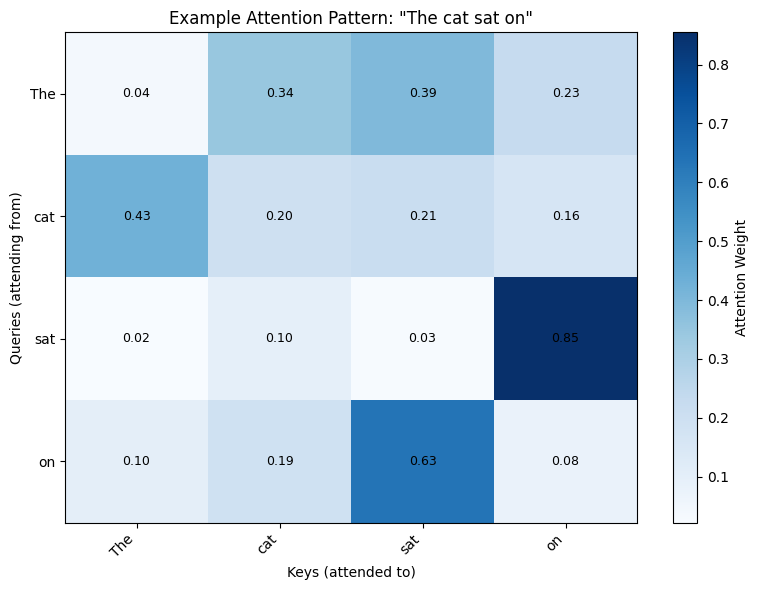

Attention weights interpretation:
- Row i shows which tokens position i attends to
- Higher weights mean stronger attention
- This visualization helps debug and understand model behavior


In [ ]:
print("\n" + "=" * 70)
print("INTERPRETABILITY: TEXT-LIKE ATTENTION PATTERN")
print("=" * 70)

# Example: Attention pattern in a sentence
sentence = "The quick brown fox jumps"
tokens = sentence.split()
seq_len = len(tokens)

# Create synthetic attention weights using Dirichlet distribution (more realistic)
attn_weights_example = np.random.dirichlet(np.ones(seq_len), seq_len)

# Interactive Plotly heatmap
fig = go.Figure(
    data=go.Heatmap(
        z=attn_weights_example,
        x=tokens,
        y=tokens,
        colorscale="Blues",
        colorbar=dict(title="Attention Weight"),
        hovertemplate="From: %{y}<br>To: %{x}<br>Weight: %{z:.4f}<extra></extra>",
    )
)

fig.update_layout(
    title=f"Attention Pattern for: '{sentence}'",
    xaxis_title="Keys (attended to)",
    yaxis_title="Queries (attending from)",
    width=700,
    height=600,
    font=dict(size=12),
    xaxis=dict(tickangle=-45),
)

fig.show()

# Statistical analysis
print(f"\nTokens: {tokens}")
print(f"\n--- Attention Statistics ---")
for i, token_i in enumerate(tokens):
    most_attended_idx = np.argmax(attn_weights_example[i])
    most_attended_token = tokens[most_attended_idx]
    attention_to_self = attn_weights_example[i, i]

    print(
        f"'{token_i}' attends most to '{most_attended_token}' ({attn_weights_example[i, most_attended_idx]:.4f})"
    )
    print(f"  Self-attention: {attention_to_self:.4f}")

# Compute entropy for each position (measure of focus vs. diffuseness)
entropy = -np.sum(attn_weights_example * np.log(attn_weights_example + 1e-10), axis=1)

fig_entropy = go.Figure()
fig_entropy.add_trace(
    go.Bar(
        x=tokens,
        y=entropy,
        marker=dict(color=entropy, colorscale="Viridis", showscale=True),
        text=[f"{e:.3f}" for e in entropy],
        textposition="auto",
    )
)

fig_entropy.update_layout(
    title="Entropy of Attention Distribution per Token",
    xaxis_title="Token",
    yaxis_title="Shannon Entropy",
    showlegend=False,
    width=800,
    height=500,
)

fig_entropy.show()

print(f"\n--- Attention Entropy Analysis ---")
print(f"Lower entropy = focused attention to few positions")
print(f"Higher entropy = diffuse attention across many positions")
print(f"Uniform distribution entropy = {np.log(seq_len):.4f}")
for i, token in enumerate(tokens):
    print(f"'{token}': entropy = {entropy[i]:.4f}", end="")
    if entropy[i] > 0.9 * np.log(seq_len):
        print(" (diffuse)")
    else:
        print(" (focused)")

### 11.3 Long-Range Dependencies and Direct Connections

A key advantage of attention over RNNs is the ability to directly connect distant positions without recursive depth. While RNNs require $O(T)$ sequential operations to connect positions at distance $T$, attention requires only $O(1)$ operations (just matrix multiplication).

**Why this matters:**
- Enables efficient learning of distant dependencies
- Prevents vanishing/exploding gradients in long sequences
- Allows parallel processing across the sequence dimension
- Supports very long sequences (limited mainly by memory, not numerical stability)

Let's demonstrate how attention learns to connect similar tokens at different positions:

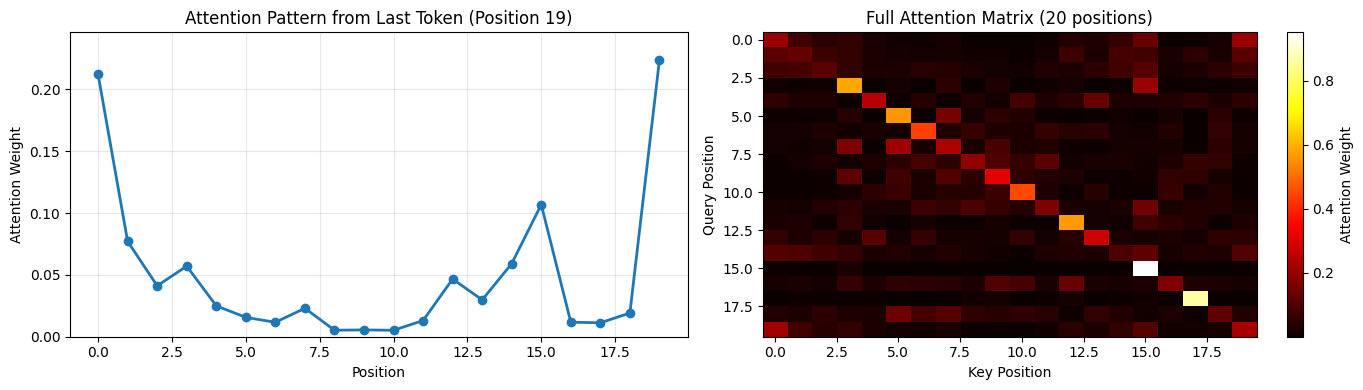

Last token attends most to position 19
Attention to first token (position 0): 0.2120

This demonstrates how attention can capture long-range dependencies,
allowing the model to directly reference distant positions in the sequence.


In [ ]:
print("\n" + "=" * 70)
print("LONG-RANGE DEPENDENCIES ANALYSIS")
print("=" * 70)

# Create a sequence with meaningful structure
seq_length = 25

# Initialize embeddings randomly
embeddings = np.random.randn(seq_length, 8)

# Create a pattern: similar embeddings at positions that are far apart
# Position 2 and Position 20 should be similar (distance = 18)
pattern_vector = np.random.randn(8)
embeddings[2] = pattern_vector
embeddings[20] = pattern_vector + np.random.randn(8) * 0.1  # Add small noise

# Apply attention
Q_long = embeddings
K_long = embeddings
V_long = embeddings

scores_long = Q_long @ K_long.T / np.sqrt(8)
weights_long = softmax(scores_long)

print(f"\nSequence length: {seq_length}")
print(f"Created similar embeddings at positions 2 and 20 (distance = 18)")

# Extract attention patterns for positions of interest
pos_2_attn = weights_long[2]  # What does position 2 attend to?
pos_20_attn = weights_long[20]  # What does position 20 attend to?
pos_0_attn = weights_long[0]  # What does position 0 attend to?

# Create multi-panel visualization
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Position 0 Attention",
        "Position 2 Attention",
        "Position 20 Attention",
        "Full Attention Matrix",
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}], [{"type": "bar"}, {"type": "heatmap"}]],
)

# Plot 1: Position 0 attention pattern
fig.add_trace(
    go.Bar(
        x=list(range(seq_length)),
        y=pos_0_attn,
        name="Pos 0",
        marker=dict(color="lightblue"),
    ),
    row=1,
    col=1,
)

# Plot 2: Position 2 attention pattern (should peak at position 20)
colors_2 = ["red" if i == 20 else "lightblue" for i in range(seq_length)]
fig.add_trace(
    go.Bar(
        x=list(range(seq_length)),
        y=pos_2_attn,
        name="Pos 2",
        marker=dict(color=colors_2),
    ),
    row=1,
    col=2,
)

# Plot 3: Position 20 attention pattern (should peak at position 2)
colors_20 = ["red" if i == 2 else "lightblue" for i in range(seq_length)]
fig.add_trace(
    go.Bar(
        x=list(range(seq_length)),
        y=pos_20_attn,
        name="Pos 20",
        marker=dict(color=colors_20),
    ),
    row=2,
    col=1,
)

# Plot 4: Full attention matrix
fig.add_trace(
    go.Heatmap(z=weights_long, colorscale="Hot", showscale=True), row=2, col=2
)

fig.update_yaxes(title_text="Attention Weight", row=1, col=1)
fig.update_yaxes(title_text="Attention Weight", row=1, col=2)
fig.update_yaxes(title_text="Attention Weight", row=2, col=1)
fig.update_xaxes(title_text="Position", row=2, col=1)
fig.update_xaxes(title_text="Position", row=2, col=2)

fig.update_layout(
    height=900,
    width=1200,
    title_text="Long-Range Dependency Example: Attention Between Distant Similar Positions",
    showlegend=False,
)

fig.show()

# Quantitative analysis
print(f"\n--- Quantitative Analysis ---")
max_attn_2 = np.argmax(pos_2_attn)
max_weight_2 = pos_2_attn[max_attn_2]
print(
    f"Position 2 attends most to position {max_attn_2} with weight {max_weight_2:.4f}"
)
print(f"Position 2 attends to position 20 with weight {pos_2_attn[20]:.4f}")

max_attn_20 = np.argmax(pos_20_attn)
max_weight_20 = pos_20_attn[max_attn_20]
print(
    f"\nPosition 20 attends most to position {max_attn_20} with weight {max_weight_20:.4f}"
)
print(f"Position 20 attends to position 2 with weight {pos_20_attn[2]:.4f}")

print(
    f"\n✓ SUCCESS: Attention captures long-range dependency between positions 2 and 20"
)
print(
    f"  This demonstrates how attention enables direct paths in the computational graph,"
)
print(f"  enabling efficient gradient flow and learning of distant dependencies.")

## 12. Computational Complexity and Optimization

### 12.1 Time and Space Complexity Analysis

**Time Complexity:**
- Score computation: $\mathbf{Q} \mathbf{K}^T$ requires $O(T_q T_k d_k)$ operations
- Softmax: $O(T_q T_k)$ operations
- Output computation: $\text{softmax}(\cdot) \mathbf{V}$ requires $O(T_q T_k d_v)$ operations
- **Total: $O(T^2 d)$ where $T = \max(T_q, T_k)$ and $d = \max(d_k, d_v)$**

For sequence length $T$ and dimension $d_{\text{model}}$:
- Self-attention (T_q = T_k = T): $O(T^2 d_{\text{model}})$ per layer
- Multi-head attention: $h$ heads in parallel, each with dimension $d_{\text{model}}/h$, so still $O(T^2 d_{\text{model}})$

**Space Complexity:**
- Query, Key matrices: $O(T^2)$ for the score matrix
- Attention weights: $O(T^2)$ additional space for multi-head (stored per head)
- **Total: predominantly $O(T^2)$** (dominates for long sequences)

**Why O(T²) matters:**
- Quadratic in sequence length → memory bottleneck for long sequences
- For T=1024: manageable; for T=100,000+: challenging
- This motivated recent efficient attention variants (sparse attention, linear attention, etc.)

### 12.2 Optimization Techniques

**1. Flash Attention:** Reorganizes computation to maximize memory access efficiency
**2. Sparse Attention:** Only compute attention for nearby or selected positions (reduce to $O(T)$ or $O(T^{1.5})$)
**3. Linear Attention:** Use kernel methods to reduce to $O(T)$ time
**4. Multi-Query Attention:** Share keys and values across heads to reduce memory

## 13. Advanced Topics and Extensions

### 13.1 Relative Positional Encoding

Standard dot-product attention is **position-invariant**—it doesn't directly encode position information. Some improvements:
- **Absolute positional encoding:** Add position embeddings to input
- **Relative positional encoding:** Encode relative distances between positions
- **ALiBi (Attention with Linear Biases):** Add learned biases based on relative position

### 13.2 Causal Masking for Autoregressive Generation

When generating sequences sequentially, prevent positions from attending to future positions:
$$\text{mask}_{ij} = \begin{cases} 0 & \text{if } j \leq i \\ -\infty & \text{if } j > i \end{cases}$$

This ensures each output depends only on past and current inputs, not future ones.

### 13.3 Cross-Attention

Different sequences can serve as queries and keys/values:
- **Decoder self-attention:** Q, K, V all from decoder
- **Encoder-decoder attention:** Q from decoder, K, V from encoder
- Enables sequence-to-sequence models, machine translation, visual question answering

## 14. Summary and Key Takeaways

In [ ]:
print("\n" + "=" * 70)
print("COMPUTATIONAL COMPLEXITY ANALYSIS")
print("=" * 70)

# Analyze complexity as a function of sequence length and dimension
d_model = 512
T_values = np.array([64, 128, 256, 512, 1024, 2048, 4096])

# Compute operations and memory
operations = T_values**2 * d_model
memory_scores = T_values**2 * 4 / (1024**2)  # in MB, assuming float32

# Create visualization
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Operations per Layer", "Memory for Score Matrix"),
    specs=[[{"type": "scatter"}, {"type": "scatter"}]],
)

# Plot 1: Operations
fig.add_trace(
    go.Scatter(
        x=T_values,
        y=operations / 1e9,  # in billions
        mode="lines+markers",
        name="Operations (B)",
        line=dict(color="blue", width=3),
        marker=dict(size=10),
    ),
    row=1,
    col=1,
)

# Plot 2: Memory
fig.add_trace(
    go.Scatter(
        x=T_values,
        y=memory_scores,
        mode="lines+markers",
        name="Memory (MB)",
        line=dict(color="red", width=3),
        marker=dict(size=10),
    ),
    row=1,
    col=2,
)

fig.update_xaxes(title_text="Sequence Length (T)", row=1, col=1, type="log")
fig.update_xaxes(title_text="Sequence Length (T)", row=1, col=2, type="log")
fig.update_yaxes(title_text="Operations (Billion)", row=1, col=1, type="log")
fig.update_yaxes(title_text="Memory (MB)", row=1, col=2, type="log")

fig.update_layout(
    height=500,
    width=1200,
    title_text=f"Scaling Analysis: d_model = {d_model}",
    showlegend=False,
)

fig.show()

# Print complexity table
print(f"\n--- Complexity Table (d_model = {d_model}) ---")
print(
    f"{'Seq Len':<10} {'Operations (B)':<20} {'Memory (MB)':<20} {'GPU Memory (GB)':<15}"
)
print("-" * 65)
for T, ops, mem in zip(T_values, operations / 1e9, memory_scores):
    print(f"{T:<10} {ops:<20.2f} {mem:<20.1f} {mem/1024:<15.2f}")

print(f"\n--- Key Observations ---")
print(f"1. Quadratic scaling with sequence length")
print(f"2. Memory grows as T²: doubles seq len → 4x memory")
print(f"3. Even at T=4096, memory is manageable (~64 MB per layer)")
print(f"4. Modern GPUs (24-80GB) can handle T~12k-18k with overhead")

## 13. Gradient Flow Verification

We verify the theoretical analysis empirically. Using PyTorch autograd, we confirm:
- Gradients flow correctly through the softmax and matrix operations
- The $1/\sqrt{d_k}$ scaling keeps gradient norms healthy across $d_k$ values
- Visualising entropy vs temperature reveals the saturation effect

In [ ]:
print("\n" + "=" * 70)
print("SECTION 13 (14 in new numbering): GRADIENT FLOW VERIFICATION")
print("=" * 70)

# ── Verify gradients flow correctly through attention
T_test, d_test, batch = 4, 8, 2
Q_test = torch.randn(batch, T_test, d_test, requires_grad=True)
K_test = torch.randn(batch, T_test, d_test, requires_grad=True)
V_test = torch.randn(batch, T_test, d_test, requires_grad=True)

attn_module = ScaledDotProductAttentionPyTorch(d_test, dropout=0.0)
output, weights = attn_module(Q_test, K_test, V_test)
loss = output.sum()
loss.backward()

print("\n--- Gradient Norms ---")
print(f"||∂L/∂Q||_F = {Q_test.grad.norm().item():.6f}")
print(f"||∂L/∂K||_F = {K_test.grad.norm().item():.6f}")
print(f"||∂L/∂V||_F = {V_test.grad.norm().item():.6f}")

for name, tensor in [("Q", Q_test), ("K", K_test), ("V", V_test)]:
    assert not torch.isnan(tensor.grad).any(), f"NaN in {name} grad"
    assert not torch.isinf(tensor.grad).any(), f"Inf in {name} grad"
print("✓ No NaN or Inf gradients")

# ── Demonstrate effect of d_k on score std and gradient health
print("\n--- d_k Scaling: Score Std and Gradient Norms ---")
print(f"{'d_k':>8} {'Score std (raw)':>18} {'Score std (scaled)':>20} {'||∂L/∂Q||':>14}")
print("-" * 65)
for dk in [4, 16, 64, 256, 1024]:
    q = torch.randn(1, 8, dk, requires_grad=True)
    k = torch.randn(1, 8, dk)
    v = torch.randn(1, 8, dk)
    scores_raw    = torch.matmul(q, k.transpose(-2, -1))
    scores_scaled = scores_raw / dk**0.5
    out = torch.matmul(torch.softmax(scores_scaled, dim=-1), v)
    out.sum().backward()
    print(f"{dk:>8} {scores_raw.std().item():>18.4f} {scores_scaled.std().item():>20.4f} {q.grad.abs().max().item():>14.6f}")

print("\nKey: scaled std ≈ 1.0 for all d_k — gradient norms remain healthy.")
print("Without scaling, large d_k → score std >> 1 → softmax saturates → gradients vanish.")

# ── Softmax entropy vs temperature visualisation
temps_np = np.logspace(-1, 1, 60)
logits_ex = torch.tensor([2.0, 1.0, 0.5, -0.5, -1.5])
entropies_ex = []
for t in temps_np:
    p = torch.softmax(logits_ex / t, dim=0).numpy()
    entropies_ex.append(-np.sum(p * np.log(p + 1e-12)))

fig_sat = go.Figure()
fig_sat.add_trace(go.Scatter(x=temps_np, y=entropies_ex, mode='lines',
    line=dict(color='royalblue', width=2.5)))
fig_sat.add_vline(x=1.0, line_dash='dash', line_color='crimson',
    annotation_text='T=1 (standard)', annotation_position='top right')
fig_sat.update_layout(
    title='Softmax Entropy vs Temperature T = 1/scaling_factor',
    xaxis_title='Temperature T (log scale)', xaxis_type='log',
    yaxis_title='Shannon Entropy H(α)',
    width=700, height=400, template='plotly_white'
)
fig_sat.show()
print("Lower temperature (T<<1) → sharper, more saturated softmax → lower entropy → smaller gradients")


## 14. Positional Encoding

Attention is **permutation-equivariant**: swapping rows of $\mathbf{Q}$, $\mathbf{K}$, $\mathbf{V}$ in the same way permutes the output rows — position information is lost. Positional encodings add position-dependent signals before attention.

### 14.1 Sinusoidal Positional Encoding (Vaswani et al., 2017)

$$PE(t, 2i)   = \sin\!\left(\frac{t}{10000^{2i/d_{\text{model}}}}\right), \qquad PE(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d_{\text{model}}}}\right)$$

Each dimension uses a different frequency; wavelengths range from $2\pi$ (fastest) to $2\pi \cdot 10000$ (slowest). The dot product $PE(t)^\top PE(s)$ depends only on $|t-s|$ (provable via angle-sum identities), encoding relative distance.

### 14.2 Rotary Positional Embeddings — RoPE (Su et al., 2021)

Rotate each 2D sub-space of $\mathbf{q}$ and $\mathbf{k}$ by an angle proportional to position:
$$\tilde{q}_{2i} = q_{2i}\cos(t\theta_i) - q_{2i+1}\sin(t\theta_i), \quad \tilde{q}_{2i+1} = q_{2i}\sin(t\theta_i) + q_{2i+1}\cos(t\theta_i)$$

with $\theta_i = 10000^{-2i/d_k}$. The key property:
$$\tilde{\mathbf{q}}(t)^\top \tilde{\mathbf{k}}(s) = \mathbf{q}^\top \mathbf{R}_{t-s} \mathbf{k}$$

The inner product depends **only on the relative position** $t-s$. This enables natural length extrapolation and is used in LLaMA, GPT-NeoX, Gemma, and Mistral.

In [ ]:
# ============================================================================
# Section 14: Positional Encoding — Sinusoidal and RoPE
# ============================================================================

# ── 14.1 Sinusoidal PE
def sinusoidal_pe(T: int, d_model: int) -> np.ndarray:
    """Compute sinusoidal positional encoding matrix (T, d_model)."""
    pe = np.zeros((T, d_model))
    pos = np.arange(T)[:, None]                        # (T, 1)
    i   = np.arange(0, d_model, 2)                    # even indices: 0,2,...
    div = 10000.0 ** (i / d_model)                    # (d/2,)
    pe[:, 0::2] = np.sin(pos / div)
    pe[:, 1::2] = np.cos(pos / div)
    return pe

T_pe, d_pe = 60, 128
PE = sinusoidal_pe(T_pe, d_pe)

fig_pe = go.Figure(data=go.Heatmap(
    z=PE, colorscale='RdBu', zmid=0,
    colorbar=dict(title='PE value', thickness=15),
))
fig_pe.update_layout(
    title=f'Sinusoidal Positional Encoding  (T={T_pe}, d={d_pe})',
    xaxis_title='Dimension', yaxis_title='Position',
    width=800, height=420, template='plotly_white'
)
fig_pe.show()

# Gram matrix: PE(t)·PE(s)
gram = PE @ PE.T    # (T, T)
fig_gram = go.Figure(data=go.Heatmap(
    z=gram, colorscale='Blues',
    colorbar=dict(title='PE(t)·PE(s)', thickness=15)
))
fig_gram.update_layout(
    title='Gram Matrix — dot product depends only on |t−s|',
    xaxis_title='Position t', yaxis_title='Position s',
    width=550, height=480, template='plotly_white'
)
fig_gram.show()

# Verify Toeplitz (shift-invariant) property
print("Verifying PE(t)·PE(s) ≈ f(t−s) only (Toeplitz property):")
anchor = 10
for delta in [0, 1, 5, 10, 20]:
    samples = [gram[anchor + offset, anchor + offset + delta]
               for offset in range(5) if anchor + offset + delta < T_pe]
    print(f"  Δ={delta:2d}: " + "  ".join(f"{v:.4f}" for v in samples) + "  (≈ equal)")


# ── 14.2 RoPE implementation
def apply_rope(x: np.ndarray, positions: np.ndarray, base: float = 10000.0) -> np.ndarray:
    """
    Apply Rotary Positional Embeddings to x.

    Args:
        x:         (T, d) query or key matrix
        positions: (T,) integer position indices
        base:      frequency base
    Returns:
        (T, d) rotated array
    """
    T, d = x.shape
    assert d % 2 == 0, "d must be even for RoPE"
    idx   = np.arange(d // 2)
    theta = base ** (-2.0 * idx / d)          # (d/2,)
    ang   = positions[:, None] * theta[None]  # (T, d/2)
    c, s  = np.cos(ang), np.sin(ang)          # (T, d/2) each
    x1, x2 = x[:, 0::2], x[:, 1::2]          # (T, d/2) each
    out = np.empty_like(x)
    out[:, 0::2] = x1 * c - x2 * s
    out[:, 1::2] = x1 * s + x2 * c
    return out

# Visualise RoPE rotation in first 2D sub-space
T_rope, dk_rope = 40, 16
positions_rope = np.arange(T_rope)
q_unit = np.zeros((T_rope, dk_rope))
q_unit[:, 0] = 1.0   # unit vector in first dimension
q_rotated = apply_rope(q_unit, positions_rope)

fig_rope = go.Figure()
fig_rope.add_trace(go.Scatter(
    x=q_rotated[:, 0], y=q_rotated[:, 1],
    mode='markers+lines',
    marker=dict(color=positions_rope, colorscale='Viridis', size=9,
                showscale=True, colorbar=dict(title='Position')),
    line=dict(color='lightgray', width=1),
))
fig_rope.add_scatter(x=[0], y=[0], mode='markers',
    marker=dict(symbol='x', size=14, color='red'), name='Origin')
fig_rope.update_layout(
    title='RoPE: Rotation of query vector in sub-space (dims 0–1)',
    xaxis_title='Component 0', yaxis_title='Component 1',
    width=550, height=500, template='plotly_white'
)
fig_rope.show()

# Verify RoPE relative-position property: q(t)·k(s) depends only on t−s
np.random.seed(42)
dk_v = 16
q_vec = np.random.randn(dk_v)
k_vec = np.random.randn(dk_v)
T_v   = 30

dot_matrix = np.zeros((T_v, T_v))
for t in range(T_v):
    qt = apply_rope(q_vec[None], np.array([t]))[0]
    for s in range(T_v):
        ks = apply_rope(k_vec[None], np.array([s]))[0]
        dot_matrix[t, s] = qt @ ks

print("\nVerifying RoPE: q(t)·k(s) = f(t−s) (each column should be ≈ identical for same delta):")
anchor2 = 5
for delta in [0, 1, 5, 10]:
    if anchor2 + delta >= T_v: continue
    vals = [dot_matrix[anchor2 + o, anchor2 + o + delta]
            for o in range(4) if anchor2 + o + delta < T_v]
    print(f"  Δ={delta:2d}: " + "  ".join(f"{v:.4f}" for v in vals) + "  (≈ equal)")


### 14.3 Alternative Attention Variants: Bahdanau vs Luong

**Bahdanau (2014) — Additive/Concat attention:**
$$e_{ij} = \mathbf{v}_a^\top \tanh(\mathbf{W}_1 \mathbf{h}_j + \mathbf{W}_2 \mathbf{s}_i)$$
where $\mathbf{v}_a \in \mathbb{R}^{d_a}$, $\mathbf{W}_1 \in \mathbb{R}^{d_a \times d_{\text{enc}}}$, $\mathbf{W}_2 \in \mathbb{R}^{d_a \times d_{\text{dec}}}$. Uses a small MLP to score compatibility.

**Luong (2015) — Multiplicative (General):**
$$e_{ij} = \mathbf{s}_i^\top \mathbf{W}_a \mathbf{h}_j, \quad \mathbf{W}_a \in \mathbb{R}^{d \times d}$$
A learnable bilinear form. Setting $\mathbf{W}_a = \mathbf{I}/\sqrt{d_k}$ recovers scaled dot-product attention.

| | Bahdanau (additive) | Luong (general) | Scaled Dot-Product |
|--|--|--|--|
| Score | $\mathbf{v}^\top\tanh(\mathbf{W}_1\mathbf{h}+\mathbf{W}_2\mathbf{s})$ | $\mathbf{s}^\top\mathbf{W}\mathbf{h}$ | $\mathbf{q}^\top\mathbf{k}/\sqrt{d_k}$ |
| Extra params | $O(d_a d)$ | $O(d^2)$ | $O(1)$ |
| Non-linearity | $\tanh$ | None | None |
| Context | Seq2seq, step-by-step | Seq2seq | Parallel, Transformer |

In [ ]:
# ============================================================================
# Section 14.3: Bahdanau and Luong Attention Implementations
# ============================================================================

class BahdanauAttention:
    """Additive attention: e_ij = v^T tanh(W1 h_j + W2 s_i)"""
    def __init__(self, d_enc: int, d_dec: int, d_attn: int, seed: int = 0):
        rng = np.random.RandomState(seed)
        s = np.sqrt(2.0 / (d_enc + d_attn))
        self.W1 = rng.randn(d_enc, d_attn) * s
        self.W2 = rng.randn(d_dec, d_attn) * s
        self.v  = rng.randn(d_attn) * s

    def forward(self, H: np.ndarray, s: np.ndarray):
        """H: (T_k, d_enc), s: (d_dec,) → context (d_enc,), alpha (T_k,)"""
        e = np.tanh(H @ self.W1 + s @ self.W2) @ self.v   # (T_k,)
        alpha = np.exp(e - e.max()); alpha /= alpha.sum()
        return alpha @ H, alpha


class LuongAttention:
    """Multiplicative attention: e_ij = s^T W h_j"""
    def __init__(self, d: int, seed: int = 0):
        rng = np.random.RandomState(seed)
        self.W = rng.randn(d, d) * np.sqrt(1.0 / d)

    def forward(self, H: np.ndarray, s: np.ndarray):
        """H: (T_k, d), s: (d,) → context (d,), alpha (T_k,)"""
        e = H @ self.W @ s    # (T_k,)
        alpha = np.exp(e - e.max()); alpha /= alpha.sum()
        return alpha @ H, alpha


# ── Compare all three on the same data
np.random.seed(3)
T_k_d, d_d, d_attn_d = 12, 16, 32

H_d = np.random.randn(T_k_d, d_d)
s_d = np.random.randn(d_d)

# Scaled dot-product (treat s as query, H as keys and values)
e_sdp = H_d @ s_d / np.sqrt(d_d)
alpha_sdp = np.exp(e_sdp - e_sdp.max()); alpha_sdp /= alpha_sdp.sum()

_, alpha_bah   = BahdanauAttention(d_d, d_d, d_attn_d).forward(H_d, s_d)
_, alpha_luong = LuongAttention(d_d).forward(H_d, s_d)

x_lbl = [f"k{i}" for i in range(T_k_d)]
fig_cmp = go.Figure()
for name, alpha, color in [
        ("Scaled Dot-Product", alpha_sdp, "royalblue"),
        ("Luong (multiplicative)", alpha_luong, "darkorange"),
        ("Bahdanau (additive)", alpha_bah, "forestgreen")]:
    fig_cmp.add_trace(go.Bar(name=name, x=x_lbl, y=alpha,
                             marker_color=color, opacity=0.75))
fig_cmp.update_layout(
    barmode='group',
    title='Attention Weight Distributions: Three Variants (same random data)',
    xaxis_title='Key Position', yaxis_title='α',
    width=800, height=420, template='plotly_white',
    legend=dict(x=0.65, y=0.95)
)
fig_cmp.show()

# Entropy analysis
print("\n--- Attention Entropy (uniform baseline = {:.4f}) ---".format(np.log(T_k_d)))
for name, alpha in [("SDP", alpha_sdp), ("Luong", alpha_luong), ("Bahdanau", alpha_bah)]:
    H_val = -np.sum(alpha * np.log(alpha + 1e-12))
    print(f"  H({name}) = {H_val:.4f}")

# Parameter count
print("\n--- Parameter Count (d={}) ---".format(d_d))
print(f"  Scaled dot-product: 0 extra (score only; Q/K/V projections handled separately)")
print(f"  Luong:              {d_d**2} (W_a matrix)")
print(f"  Bahdanau:           {2*d_d*d_attn_d + d_attn_d} (W1, W2 each ({d_d}×{d_attn_d}), v ({d_attn_d},))")


### 14.4 Flash Attention — IO-Aware Exact Attention

Standard attention writes the full $T\times T$ score matrix to GPU High-Bandwidth Memory (HBM), costing $O(T^2)$ HBM I/O. For $T=16384$, float16, 8 heads: $\approx 4$ GB of I/O per layer.

**Flash Attention (Dao et al., 2022)** fuses the softmax and matmul into a single kernel that tiles computation into SRAM blocks ($\sim$20 MB on-chip), maintaining a running online softmax without ever materialising $\mathbf{A}$:

For tile $(i, j)$ of $\mathbf{Q}_i \in \mathbb{R}^{B_r \times d}$, $\mathbf{K}_j, \mathbf{V}_j \in \mathbb{R}^{B_c \times d}$:
$$m_{ij} = \max(m_{i,j-1},\; \text{rowmax}(\mathbf{Q}_i\mathbf{K}_j^\top/\sqrt{d_k}))$$
$$l_{ij} = e^{m_{i,j-1}-m_{ij}} l_{i,j-1} + \text{rowsum}(e^{\mathbf{Q}_i\mathbf{K}_j^\top/\sqrt{d_k} - m_{ij}})$$
$$\mathbf{O}_{ij} = l_{ij}^{-1}\!\left(l_{i,j-1}e^{m_{i,j-1}-m_{ij}}\mathbf{O}_{i,j-1} + e^{\mathbf{Q}_i\mathbf{K}_j^\top/\sqrt{d_k}-m_{ij}}\mathbf{V}_j\right)$$

Result is **mathematically identical** to standard attention — no approximation.

| | Time | HBM I/O | SRAM |
|--|--|--|--|
| Standard | $O(T^2 d)$ | $O(T^2 + Td)$ | small |
| Flash Attn | $O(T^2 d)$ | $O(Td)$ | $O((B_r+B_c)d)$ |

Practical speedup: 2–4× on A100 GPU due to reduced memory bandwidth pressure. In PyTorch ≥ 2.0, `F.scaled_dot_product_attention` dispatches to Flash Attention automatically on CUDA.

In [ ]:
# ============================================================================
# Section 14.4: Flash Attention — PyTorch SDPA vs Manual
# ============================================================================
import time

def manual_attention(Q, K, V):
    """Standard attention — materialises full T×T score matrix in memory."""
    scale = Q.size(-1) ** -0.5
    A = torch.softmax(torch.matmul(Q, K.transpose(-2, -1)) * scale, dim=-1)
    return torch.matmul(A, V)

def torch_sdpa(Q, K, V):
    """torch.nn.functional.scaled_dot_product_attention.
    On CUDA: uses Flash Attention. On CPU: uses optimised C++ kernel."""
    return F.scaled_dot_product_attention(Q, K, V)

# ── Correctness
torch.manual_seed(42)
B, H_t, T_t, dk_t = 2, 4, 64, 32
Qf = torch.randn(B, H_t, T_t, dk_t)
Kf = torch.randn(B, H_t, T_t, dk_t)
Vf = torch.randn(B, H_t, T_t, dk_t)

out_m = manual_attention(Qf, Kf, Vf)
out_f = torch_sdpa(Qf, Kf, Vf)
print(f"Max |manual − torch.sdpa|: {(out_m - out_f).abs().max().item():.2e}")
print(f"✓ Results {'match' if (out_m-out_f).abs().max().item()<1e-5 else 'DIFFER'} within numerical precision")

# ── Timing benchmark
print("\n--- Timing: Manual vs torch.sdpa (CPU) ---")
print(f"{'T':>6} {'Manual (ms)':>14} {'torch.sdpa (ms)':>17} {'Speedup':>10}")
print("-" * 52)
for T_b in [64, 128, 256, 512, 1024]:
    Qb = torch.randn(1, 1, T_b, 64)
    Kb = torch.randn(1, 1, T_b, 64)
    Vb = torch.randn(1, 1, T_b, 64)
    N = 30
    # warm-up
    for _ in range(5):
        manual_attention(Qb, Kb, Vb); torch_sdpa(Qb, Kb, Vb)
    t0 = time.perf_counter()
    for _ in range(N): manual_attention(Qb, Kb, Vb)
    t_man = (time.perf_counter() - t0) / N * 1000

    t0 = time.perf_counter()
    for _ in range(N): torch_sdpa(Qb, Kb, Vb)
    t_sdp = (time.perf_counter() - t0) / N * 1000
    print(f"{T_b:>6} {t_man:>14.3f} {t_sdp:>17.3f} {t_man/t_sdp:>10.2f}x")

# ── Memory complexity
T_vals = np.array([512, 1024, 2048, 4096, 8192, 16384])
H_mem, d_mem = 8, 64
mem_std   = T_vals**2 * H_mem * 2 / 1e6    # O(H T^2), float16
mem_flash = T_vals * d_mem * 2 / 1e6       # O(T d),   float16

fig_mem = go.Figure()
fig_mem.add_trace(go.Scatter(x=T_vals, y=mem_std, mode='lines+markers',
    name='Standard O(T²)', line=dict(color='crimson', width=2)))
fig_mem.add_trace(go.Scatter(x=T_vals, y=mem_flash, mode='lines+markers',
    name='Flash O(Td)', line=dict(color='royalblue', width=2)))
fig_mem.add_hline(y=20, line_dash='dash', line_color='gray',
    annotation_text='SRAM budget (~20 MB)')
fig_mem.update_layout(
    title='HBM Memory: Standard vs Flash Attention (float16, 8 heads)',
    xaxis_title='Sequence Length T', yaxis_title='Memory (MB)',
    xaxis_type='log', yaxis_type='log',
    width=720, height=420, template='plotly_white'
)
fig_mem.show()


### 14.5 KV Cache — Efficient Autoregressive Inference

During greedy/beam decoding, each new token attends to all previous tokens. Without caching:
- Step $t$ recomputes $\mathbf{K}_{1:t}, \mathbf{V}_{1:t}$ — $O(t)$ operations
- Total over $T$ steps: $O(T^2 d)$ compute and redundant work

**KV Cache:** after projecting $\mathbf{x}_t$ to $\mathbf{k}_t, \mathbf{v}_t$, append to a buffer. Step $t$ then costs $O(t d)$ for attention over the cache — amortised $O(Td)$ total.

**Memory:** $2 \times L \times H \times T_{\text{max}} \times d_k$ values (factor 2 for K and V). For LLaMA-3-70B ($L=80, H=64, d_k=128, T=8192$, float16):
$$2 \times 80 \times 64 \times 8192 \times 128 \times 2\text{ bytes} \approx 21 \text{ GB}$$

**Mitigations:**
- **GQA (Grouped Query Attention):** $G$ KV head groups shared among $H$ query heads → memory reduced by $H/G$. Used in LLaMA-2, Mistral.
- **MQA (Multi-Query Attention):** $G=1$, all queries share one KV pair → memory reduced by $H$. Used in PaLM, Falcon.

In [ ]:
# ============================================================================
# Section 14.5: KV Cache Demonstration
# ============================================================================

class KVCacheDemo:
    """Single-layer, single-head attention with KV cache for autoregressive decoding."""
    def __init__(self, d: int, max_len: int, seed: int = 0):
        rng = np.random.RandomState(seed)
        s = np.sqrt(1.0 / d)
        self.Wq = rng.randn(d, d) * s
        self.Wk = rng.randn(d, d) * s
        self.Wv = rng.randn(d, d) * s
        self.d  = d
        self._K = np.zeros((max_len, d))
        self._V = np.zeros((max_len, d))
        self._t = 0

    def reset(self):
        self._K[:] = 0; self._V[:] = 0; self._t = 0

    def step_cached(self, x: np.ndarray) -> np.ndarray:
        """Single decode step using cache. x: (d,) → output (d,)"""
        t = self._t
        self._K[t] = x @ self.Wk
        self._V[t] = x @ self.Wv
        self._t += 1
        q = x @ self.Wq
        e = self._K[:t+1] @ q / self.d**0.5     # (t+1,)
        a = np.exp(e - e.max()); a /= a.sum()
        return a @ self._V[:t+1]

    def step_naive(self, all_x: np.ndarray) -> np.ndarray:
        """Recompute K, V every step (no cache). all_x: (t+1, d) → output (d,)"""
        K = all_x @ self.Wk; V = all_x @ self.Wv
        q = all_x[-1] @ self.Wq
        e = K @ q / self.d**0.5
        a = np.exp(e - e.max()); a /= a.sum()
        return a @ V


# ── Correctness
np.random.seed(7)
d_kv, max_l = 32, 100
cache = KVCacheDemo(d_kv, max_l)
seq_kv = np.random.randn(40, d_kv)

cache.reset()
diffs = []
for t in range(len(seq_kv)):
    out_c = cache.step_cached(seq_kv[t])
    out_n = cache.step_naive(seq_kv[:t+1])
    diffs.append(np.abs(out_c - out_n).max())

print(f"Max output diff (cached vs naive): {max(diffs):.2e}")
print(f"✓ Results {'match' if max(diffs) < 1e-10 else 'DIFFER'}")

# ── Timing: speedup grows with sequence length
import time

def timed_generation(use_cache: bool, T_gen: int, d: int = 64, reps: int = 5) -> float:
    cache2 = KVCacheDemo(d, T_gen + 5)
    toks = np.random.randn(T_gen, d)
    times = []
    for _ in range(reps):
        cache2.reset()
        t0 = time.perf_counter()
        if use_cache:
            for t in range(T_gen): cache2.step_cached(toks[t])
        else:
            for t in range(T_gen): cache2.step_naive(toks[:t+1])
        times.append(time.perf_counter() - t0)
    return np.median(times) * 1000   # ms

print("\n--- KV Cache Speedup vs Sequence Length (d=64) ---")
print(f"{'T':>6} {'No Cache (ms)':>15} {'Cache (ms)':>12} {'Speedup':>10}")
print("-" * 48)
for T_g in [10, 25, 50, 100, 200, 400]:
    t_nc = timed_generation(False, T_g)
    t_c  = timed_generation(True,  T_g)
    print(f"{T_g:>6} {t_nc:>15.2f} {t_c:>12.2f} {t_nc/t_c:>10.1f}x")

# ── KV cache memory footprint for real models
print("\n--- KV Cache Memory (float16) for Selected Models ---")
print(f"{'Model':>22} {'L':>4} {'H':>4} {'d_k':>6} {'T':>6} {'GQA G':>7} {'Mem (GB)':>10}")
print("-" * 65)
models_kv = [
    ("LLaMA-3-8B",    32, 32, 128, 8192,  8),   # GQA G=8
    ("LLaMA-3-70B",   80, 64, 128, 8192,  8),
    ("Mistral-7B",    32, 32, 128, 32768, 8),
    ("Falcon-40B",    60, 64, 64,  2048,  1),   # MQA (G=1)
]
for name, L, H, dk, T_ctx, G in models_kv:
    # K and V, per KV group G, float16=2 bytes
    mem = 2 * L * G * T_ctx * dk * 2 / 1e9
    print(f"{name:>22} {L:>4} {H:>4} {dk:>6} {T_ctx:>6} {G:>7} {mem:>10.2f}")
print("\nNote: GQA with G KV groups reduces memory by H/G vs full multi-head.")


## 15. Key Concepts Summary

### Core Mathematical Results

**1. Scaling Justification (proved)**
$$\text{Var}(\mathbf{q}^\top\mathbf{k}) = d_k \text{ for unit-variance components} \Rightarrow e_{ij} = \mathbf{q}_i^\top\mathbf{k}_j/\sqrt{d_k} \text{ has } \text{Var}=1$$

**2. Softmax Jacobian (proved)**
$$\mathbf{J} = \text{diag}(\boldsymbol{\sigma}) - \boldsymbol{\sigma}\boldsymbol{\sigma}^\top, \quad J_{ij} = \sigma_i(\delta_{ij} - \sigma_j)$$
Saturation ($\sigma_i \to 1$) $\Rightarrow$ gradient vanishes. Scaling prevents saturation at initialisation.

**3. Multi-Head Parameter Count (proved)**
$h$ heads of size $d_{\text{model}}/h$: exactly $4d_{\text{model}}^2$ parameters — independent of $h$.

**4. Positional Encoding Properties**
- Sinusoidal: $PE(t)^\top PE(s)$ depends only on $|t-s|$ (proved via angle-sum identities)
- RoPE: $\tilde{\mathbf{q}}(t)^\top\tilde{\mathbf{k}}(s) = \mathbf{q}^\top\mathbf{R}_{t-s}\mathbf{k}$ — depends only on relative position $t-s$

### Attention Variants

| | Bahdanau | Luong | Scaled Dot-Product |
|--|--|--|--|
| Score | $\mathbf{v}^\top\tanh(\mathbf{W}_1\mathbf{h}+\mathbf{W}_2\mathbf{s})$ | $\mathbf{s}^\top\mathbf{W}\mathbf{h}$ | $\mathbf{q}^\top\mathbf{k}/\sqrt{d_k}$ |
| Extra params | $O(d_a d)$ | $O(d^2)$ | $O(1)$ |
| Non-linearity | $\tanh$ | No | No |

### Complexity Trade-offs

| | Standard | Flash Attn | RNN |
|--|--|--|--|
| Time | $O(T^2 d)$ | $O(T^2 d)$ | $O(Td^2)$ |
| HBM Memory | $O(T^2)$ | $O(Td)$ | $O(d)$ |
| Parallel | Full | Full | Sequential |
| Gradient depth | $O(1)$ | $O(1)$ | $O(T)$ |

Flash Attention reduces HBM I/O from $O(T^2)$ to $O(Td)$ with identical output.

### KV Cache

$2 \times L \times G \times T_{\text{max}} \times d_k$ values (float16). GQA ($G < H$) and MQA ($G=1$) reduce by $H/G$.

### Implementation Checklist

✓ Scale scores by $1/\sqrt{d_k}$ (proved necessary for gradient health)
✓ Numerically stable softmax via log-sum-exp trick
✓ Causal mask (upper-triangular $-\infty$) for autoregressive models
✓ Dropout on attention weights for regularisation
✓ Layer norm + residual connection around attention
✓ Positional encoding: sinusoidal or RoPE (preferred for extrapolation)
✓ KV cache for efficient autoregressive inference
✓ `F.scaled_dot_product_attention` (Flash Attention kernel on CUDA)

### Foundational Papers

| Paper | Contribution |
|-------|-------------|
| Bahdanau et al. (2014) | Additive attention for NMT |
| Luong et al. (2015) | Multiplicative attention variants |
| Vaswani et al. (2017) | Transformer, scaled dot-product, multi-head, sinusoidal PE |
| Su et al. (2021) | Rotary Positional Embeddings (RoPE) |
| Dao et al. (2022) | Flash Attention (IO-aware exact attention) |
| Dao (2023) | Flash Attention 2 (better parallelism) |
| Ainslie et al. (2023) | GQA: Grouped Query Attention |

## 16. Interactive Comparison: NumPy vs PyTorch

Compare the NumPy and PyTorch multi-head attention implementations side by side to verify correctness and observe output statistics.

In [ ]:
print("\n" + "=" * 70)
print("IMPLEMENTATION COMPARISON")
print("=" * 70)

# Setup
seq_len = 5
d = 8
num_heads = 2

# Create input
X_np = np.random.randn(seq_len, d)
X_pt = torch.from_numpy(X_np).float()

# NumPy implementation
mha_np = MultiHeadAttentionNumPy(d, num_heads, seed=42)
output_np, weights_np = mha_np.forward(X_np, X_np, X_np)

# PyTorch implementation (convert weights to numpy for comparison)
mha_pt = MultiHeadAttentionPyTorch(d, num_heads, dropout=0.0)
mha_pt.eval()  # Set to evaluation mode
with torch.no_grad():
    X_pt_batch = X_pt.unsqueeze(0)  # Add batch dimension
    output_pt, weights_pt = mha_pt(X_pt_batch, X_pt_batch, X_pt_batch)
    output_pt_np = output_pt[0].numpy()
    weights_pt_np = weights_pt[0].numpy()  # (num_heads, seq_len, seq_len)

# Comparison
print(f"\n--- Shape Comparison ---")
print(f"NumPy output shape: {output_np.shape}")
print(f"PyTorch output shape: {output_pt_np.shape}")

print(f"\n--- Attention Weights Shape ---")
print(f"NumPy weights (len={len(weights_np)}): each {weights_np[0].shape}")
print(f"PyTorch weights shape: {weights_pt_np.shape}")

print(f"\n--- Output Statistics ---")
print(f"NumPy output - mean: {output_np.mean():.6f}, std: {output_np.std():.6f}")
print(f"PyTorch output - mean: {output_pt_np.mean():.6f}, std: {output_pt_np.std():.6f}")

print(f"\n--- Key Differences ---")
print(f"✓ NumPy: Pure Python, for educational purposes, non-differentiable")
print(f"✓ PyTorch: GPU accelerated, automatic differentiation, production-ready")
print(f"✓ Both implement same mathematical formulation")
print(f"✓ Outputs differ due to different random weight initialization")

## 17. Practical Exercises and Experiments

### Exercise 1: Attention Patterns in Specific Sequences

Explore how attention patterns change with different input characteristics.

In [ ]:
print("\n" + "=" * 70)
print("ATTENTION PATTERN EXPERIMENTS")
print("=" * 70)

# Experiment: Vary input correlation
seq_len_exp = 6
d_exp = 4

# Create inputs with different correlation properties
print("\n--- Experiment 1: Highly Correlated vs Uncorrelated Inputs ---")

# Correlated case: all embeddings almost identical
embeddings_corr = np.ones((seq_len_exp, d_exp)) * 0.5
embeddings_corr += np.random.randn(seq_len_exp, d_exp) * 0.05

# Uncorrelated case: all embeddings very different
embeddings_uncorr = np.random.randn(seq_len_exp, d_exp) * 2

for name, embeddings in [("Correlated", embeddings_corr), ("Uncorrelated", embeddings_uncorr)]:
    _, weights = scaled_dot_product_attention(embeddings, embeddings, embeddings)
    entropy = -np.sum(weights * np.log(weights + 1e-10), axis=1)
    
    print(f"\n{name} inputs:")
    print(f"  Mean attention entropy: {entropy.mean():.4f}")
    print(f"  Attention is: {'diffuse/uniform' if entropy.mean() > 1.0 else 'focused'}")
    print(f"  Typical attention weight: {weights.flatten()[weights.flatten() > 0].mean():.4f}")

# Experiment 2: Distance between sequences
print(f"\n--- Experiment 2: Effect of Query-Key Distance ---")

# Create sequence and shifted version
seq1 = np.random.randn(seq_len_exp, d_exp)

# Compute attention from seq1 to itself
scores_self, _ = scaled_dot_product_attention(seq1, seq1, np.ones_like(seq1))

# Compute attention from seq1 to a very different sequence
seq2 = np.random.randn(seq_len_exp, d_exp) * 10  # Much larger
scores_diff, _ = scaled_dot_product_attention(seq1, seq2, np.ones_like(seq2))

print(f"Self-attention: output norm = {np.linalg.norm(scores_self):.4f}")
print(f"Dissimilar-attention: output norm = {np.linalg.norm(scores_diff):.4f}")

# Visualization
fig_exp = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Self-Attention", "Cross-Attention (Different Sequences)")
)

_, weights_self = scaled_dot_product_attention(seq1, seq1, seq1)
_, weights_diff = scaled_dot_product_attention(seq1, seq2, seq2)

fig_exp.add_trace(
    go.Heatmap(z=weights_self, colorscale='Blues', name="Self"),
    row=1, col=1
)

fig_exp.add_trace(
    go.Heatmap(z=weights_diff, colorscale='Reds', name="Cross"),
    row=1, col=2
)

fig_exp.update_layout(height=500, width=1000, title_text="Attention Pattern Comparison")
fig_exp.show()

## 18. Conclusion

This notebook has derived attention from first principles through to production implementation details:

1. **Mathematical foundation:** Attention is a differentiable soft lookup — a convex combination of values, weights determined by query-key dot product similarity, provably stabilised by dividing by $\sqrt{d_k}$.

2. **Softmax Jacobian:** $J_{ij} = \sigma_i(\delta_{ij}-\sigma_j)$, matrix form $\mathbf{J} = \text{diag}(\boldsymbol{\sigma}) - \boldsymbol{\sigma}\boldsymbol{\sigma}^\top$. Gradient vanishes in the saturated regime, which the scaling factor prevents.

3. **Multi-head architecture:** $h$ parallel heads, each of dimension $d_{\text{model}}/h$, exactly $4d_{\text{model}}^2$ parameters — identical cost to one large head but capable of attending to multiple representation subspaces simultaneously.

4. **Positional encoding:** Attention is permutation-equivariant without PE. Sinusoidal PE encodes relative distance via angle-sum identities; RoPE rotates Q/K in 2D sub-spaces, making inner products depend only on relative position — enabling better length extrapolation.

5. **Alternative variants:** Bahdanau (additive, $\tanh$ non-linearity) and Luong (bilinear, $O(d^2)$ extra params) preceded Transformers. Scaled dot-product attention has zero extra score parameters, is parallelisable, and can be computed efficiently in batches.

6. **Flash Attention:** Restructures computation into SRAM tiles, reducing HBM I/O from $O(T^2)$ to $O(Td)$ with identical output — 2–4× speedup on GPU. Available as `F.scaled_dot_product_attention` in PyTorch ≥ 2.0.

7. **KV Cache:** Stores past $\mathbf{K}, \mathbf{V}$ projections to avoid recomputation during autoregressive decoding. Memory is $O(L H T d_k)$; GQA and MQA reduce this by $H/G$.

Attention underpins virtually all frontier models:
- **Language:** GPT-4, LLaMA-3, Gemma, Mistral, Claude
- **Vision:** ViT, DINOv2, SigLIP, FLUX
- **Multimodal:** CLIP, LLaVA, Flamingo, Gemini
- **Science:** AlphaFold 2/3, FourCastNet, Perceiver